# GPU V3 — Tăng tốc khoảng cách patch bằng Prefix Sum / Running Sum

Notebook này đánh giá thiết kế GPU V3 mới cho thuật toán Non-Local Means (NLM).

## Ý tưởng chính

GPU V1 khai thác song song ở mức pixel: mỗi CUDA thread xử lý một output pixel.

GPU V2 giảm việc đọc lặp từ Global Memory bằng cách tải tile + halo vào Shared Memory để các thread trong cùng block tái sử dụng dữ liệu.

GPU V3 nhắm đến một nút thắt khác: **việc tính lại khoảng cách patch nhiều lần**.

Thay vì cộng lại từng squared difference của toàn bộ patch cho mỗi candidate, GPU V3 tạo squared-difference map cho từng displacement và dùng running sum theo hai chiều để lấy tổng patch nhanh hơn.

## Cấu hình benchmark chính

- Kích thước ảnh: `512 × 512`
- Patch size: `7 × 7`
- Search window: `21 × 21`
- CUDA block: `16 × 16`

GPU V1, GPU V2 và GPU V3 đều phải dùng cùng input và cùng cấu hình để việc so sánh runtime là công bằng.

In [1]:

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Thư mục gốc dự án:", PROJECT_ROOT)


Thư mục gốc dự án: e:\Lap trinh song song ud\gpu_dense_vector_retrieval


## Import thư viện và các hàm cần thiết

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cupy as cp

from src.nlm.config import NLMConfig
from src.nlm.image_utils import create_camera_test_image, add_gaussian_noise
from src.nlm.metrics import calculate_psnr, calculate_ssim
from src.nlm.benchmark import benchmark_cuda_kernel, benchmark_gpu_end_to_end

from src.nlm.gpu_v1 import (
    nlm_gpu_v1,
    create_gpu_v1_kernel_launcher,
)

from src.nlm.gpu_v2 import nlm_gpu_v2

try:
    from src.nlm.gpu_v2 import create_gpu_v2_kernel_launcher
    GPU_V2_LAUNCHER_API = "create_gpu_v2_kernel_launcher"
except ImportError:
    from src.nlm.gpu_v2 import prepare_gpu_v2_kernel_launch
    GPU_V2_LAUNCHER_API = "prepare_gpu_v2_kernel_launch"

from src.nlm.gpu_v3 import (
    nlm_gpu_v3,
    create_gpu_v3_kernel_launcher,
)

print("API launcher GPU V2:", GPU_V2_LAUNCHER_API)


API launcher GPU V2: prepare_gpu_v2_kernel_launch


## Thông tin GPU CUDA

In [3]:

device = cp.cuda.Device()
props = cp.cuda.runtime.getDeviceProperties(device.id)

print("CUDA device ID:", device.id)
print("Tên GPU:", props["name"].decode() if isinstance(props["name"], bytes) else props["name"])
print("Compute capability:", props["major"], ".", props["minor"], sep="")


CUDA device ID: 0
Tên GPU: NVIDIA GeForce RTX 3050 Laptop GPU
Compute capability:8.6


## Cấu hình thí nghiệm với workload lớn hơn

GPU V3 được đánh giá ở cấu hình patch/search lớn hơn để chi phí tính khoảng cách patch trở nên rõ rệt hơn.

Notebook vẫn giữ kích thước ảnh ở `512 × 512`, nhưng tăng:

- patch size từ `3 × 3` lên `7 × 7`;
- search window từ `7 × 7` lên `21 × 21`.

GPU V1, V2 và V3 sẽ cùng chạy trên cấu hình này để bảo đảm **cùng workload**.

In [4]:

config = NLMConfig(
    image_size=512,
    noise_sigma=0.08,
    patch_size=7,
    search_window_size=21,
    h=0.12,
    random_seed=42,
    block_size_x=16,
    block_size_y=16,
)

patch_radius = config.patch_size // 2
search_radius = config.search_window_size // 2
halo_radius = patch_radius + search_radius

print("Kích thước ảnh:", config.image_size)
print("Patch size:", config.patch_size)
print("Search window:", config.search_window_size)
print("Patch radius:", patch_radius)
print("Search radius:", search_radius)
print("Halo radius:", halo_radius)
print("Block size:", (config.block_size_x, config.block_size_y))


Kích thước ảnh: 512
Patch size: 7
Search window: 21
Patch radius: 3
Search radius: 10
Halo radius: 13
Block size: (16, 16)


## Mức tăng khối lượng tính toán

In [5]:

original_candidates = 7 * 7
original_patch_elements = 3 * 3
original_work = original_candidates * original_patch_elements

large_candidates = config.search_window_size ** 2
large_patch_elements = config.patch_size ** 2
large_work = large_candidates * large_patch_elements

print("Số phép so sánh phần tử/output pixel ở cấu hình 3x3 / 7x7:", original_work)
print("Số phép so sánh phần tử/output pixel ở cấu hình 7x7 / 21x21:", large_work)
print("Mức tăng workload:", f"{large_work / original_work:.1f}×")


Số phép so sánh phần tử/output pixel ở cấu hình 3x3 / 7x7: 441
Số phép so sánh phần tử/output pixel ở cấu hình 7x7 / 21x21: 21609
Mức tăng workload: 49.0×


## Tạo ảnh sạch và ảnh nhiễu dùng chung cho cả ba phiên bản

In [6]:
clean_image = create_camera_test_image(config.image_size)

# Tạo Gaussian noise trực tiếp để bảo đảm reproducibility.
# Không truyền random_seed vào add_gaussian_noise vì hàm hiện tại
# trong project không nhận keyword này.
rng = np.random.default_rng(config.random_seed)

gaussian_noise = rng.normal(
    loc=0.0,
    scale=config.noise_sigma,
    size=clean_image.shape,
).astype(np.float32)

noisy_image = np.clip(
    clean_image + gaussian_noise,
    0.0,
    1.0,
).astype(np.float32)

print("Ảnh sạch:", clean_image.shape, clean_image.dtype)
print("Ảnh nhiễu:", noisy_image.shape, noisy_image.dtype)
print(
    "Khoảng giá trị:",
    float(noisy_image.min()),
    "đến",
    float(noisy_image.max()),
)

Ảnh sạch: (512, 512) float32
Ảnh nhiễu: (512, 512) float32
Khoảng giá trị: 0.0 đến 1.0


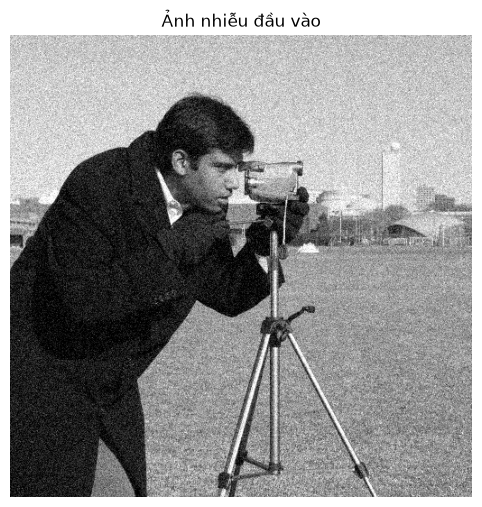

In [7]:

plt.figure(figsize=(6, 6))
plt.imshow(noisy_image, cmap="gray", vmin=0.0, vmax=1.0)
plt.title("Ảnh nhiễu đầu vào")
plt.axis("off")
plt.show()


## Chạy GPU V1, GPU V2 và GPU V3

Cả ba phiên bản đều sử dụng cùng:

- ảnh nhiễu;
- patch size;
- search window;
- tham số lọc `h`.

Điều này giúp việc so sánh giữa V1, V2 và V3 là công bằng.

In [8]:

gpu_v1_output = nlm_gpu_v1(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=(config.block_size_x, config.block_size_y),
)

gpu_v2_output = nlm_gpu_v2(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=(config.block_size_x, config.block_size_y),
)

gpu_v3_output = nlm_gpu_v3(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=(config.block_size_x, config.block_size_y),
)

print("V1:", gpu_v1_output.shape, gpu_v1_output.dtype)
print("V2:", gpu_v2_output.shape, gpu_v2_output.dtype)
print("V3:", gpu_v3_output.shape, gpu_v3_output.dtype)


V1: (512, 512) float32
V2: (512, 512) float32
V3: (512, 512) float32


## Kiểm tra tính đúng đắn

In [9]:

v3_vs_v1_max_error = float(np.max(np.abs(gpu_v3_output - gpu_v1_output)))
v3_vs_v2_max_error = float(np.max(np.abs(gpu_v3_output - gpu_v2_output)))

v3_vs_v1_allclose = np.allclose(gpu_v3_output, gpu_v1_output, atol=1e-5, rtol=1e-5)
v3_vs_v2_allclose = np.allclose(gpu_v3_output, gpu_v2_output, atol=1e-5, rtol=1e-5)

correctness_table = pd.DataFrame([
    {
        "So sánh": "GPU V3 vs GPU V1",
        "Sai số tuyệt đối lớn nhất": v3_vs_v1_max_error,
        "Allclose": v3_vs_v1_allclose,
    },
    {
        "So sánh": "GPU V3 vs GPU V2",
        "Sai số tuyệt đối lớn nhất": v3_vs_v2_max_error,
        "Allclose": v3_vs_v2_allclose,
    },
])

correctness_table


,So sánh,Sai số tuyệt đối lớn nhất,Allclose
0,GPU V3 vs GPU V1,0.000001,True
1,GPU V3 vs GPU V2,0.000001,True


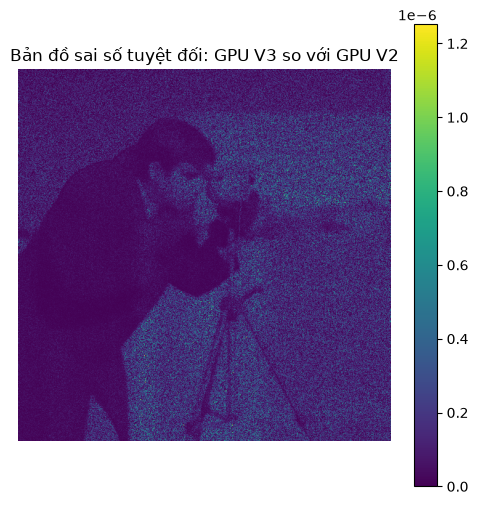

In [10]:

error_map = np.abs(gpu_v3_output - gpu_v2_output)

plt.figure(figsize=(6, 6))
plt.imshow(error_map, cmap="viridis")
plt.title("Bản đồ sai số tuyệt đối: GPU V3 so với GPU V2")
plt.axis("off")
plt.colorbar()
plt.show()


## Đánh giá chất lượng ảnh bằng PSNR và SSIM

In [11]:

quality_table = pd.DataFrame([
    {
        "Phiên bản": "GPU V1",
        "PSNR": calculate_psnr(clean_image, gpu_v1_output),
        "SSIM": calculate_ssim(clean_image, gpu_v1_output),
    },
    {
        "Phiên bản": "GPU V2",
        "PSNR": calculate_psnr(clean_image, gpu_v2_output),
        "SSIM": calculate_ssim(clean_image, gpu_v2_output),
    },
    {
        "Phiên bản": "GPU V3",
        "PSNR": calculate_psnr(clean_image, gpu_v3_output),
        "SSIM": calculate_ssim(clean_image, gpu_v3_output),
    },
])

quality_table


,Phiên bản,PSNR,SSIM
0,GPU V1,27.925106,0.731726
1,GPU V2,27.925106,0.731726
2,GPU V3,27.925106,0.731726


## Chuẩn bị launcher để đo GPU compute-only

Với GPU V1 và GPU V2, compute-only tương ứng với phần thực thi CUDA kernel của NLM.

GPU V3 là một **pipeline gồm nhiều kernel**, vì vậy thời gian compute-only của V3 phải bao gồm toàn bộ các bước CUDA cần thiết cho running-sum pipeline, nhưng không bao gồm:

- truyền dữ liệu Host-to-Device;
- truyền dữ liệu Device-to-Host;
- phần chuẩn bị và cấp phát bộ nhớ một lần ở phía Python.

Do đó launcher của V3 phải chạy toàn bộ GPU compute pipeline, không chỉ đo một kernel riêng lẻ.

In [12]:

v1_launcher, v1_output_gpu = create_gpu_v1_kernel_launcher(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=(config.block_size_x, config.block_size_y),
)

if GPU_V2_LAUNCHER_API == "create_gpu_v2_kernel_launcher":
    v2_launcher, v2_output_gpu = create_gpu_v2_kernel_launcher(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=config.search_window_size,
        h=config.h,
        block_size=(config.block_size_x, config.block_size_y),
    )
else:
    v2_prepared = prepare_gpu_v2_kernel_launch(
        image=noisy_image,
        patch_size=config.patch_size,
        search_window_size=config.search_window_size,
        h=config.h,
        block_size=(config.block_size_x, config.block_size_y),
    )
    v2_launcher = v2_prepared["kernel_launcher"]
    v2_output_gpu = v2_prepared.get("output_gpu")

v3_launcher, v3_output_gpu = create_gpu_v3_kernel_launcher(
    image=noisy_image,
    patch_size=config.patch_size,
    search_window_size=config.search_window_size,
    h=config.h,
    block_size=(config.block_size_x, config.block_size_y),
)

print("Đã chuẩn bị xong các launcher compute-only.")


Đã chuẩn bị xong các launcher compute-only.


## Warm-up GPU trước khi benchmark

In [13]:

for _ in range(20):
    v1_launcher()
    v2_launcher()
    v3_launcher()

cp.cuda.get_current_stream().synchronize()

print("Đã hoàn tất warm-up.")


Đã hoàn tất warm-up.


## Benchmark thời gian GPU compute-only

In [14]:

v1_compute_benchmark = benchmark_cuda_kernel(
    kernel_launcher=v1_launcher,
    warmup_runs=10,
    measured_runs=50,
)

v2_compute_benchmark = benchmark_cuda_kernel(
    kernel_launcher=v2_launcher,
    warmup_runs=10,
    measured_runs=50,
)

v3_compute_benchmark = benchmark_cuda_kernel(
    kernel_launcher=v3_launcher,
    warmup_runs=10,
    measured_runs=50,
)

v1_compute_benchmark, v2_compute_benchmark, v3_compute_benchmark


({'times_ms': array([38.61811066, 38.23718262, 38.06310272, 37.87980652, 37.38009644,
         37.37599945, 37.52755356, 38.1757431 , 38.96524811, 38.37030411,
         38.04057693, 37.90745544, 37.80812836, 37.4517746 , 37.3678093 ,
         37.31763077, 37.07699203, 37.08415985, 37.56236649, 37.71699142,
         37.36883163, 37.38726425, 37.81631851, 37.82348633, 37.8204155 ,
         37.83679962, 37.82963181, 37.82758331, 37.83270264, 37.71392059,
         37.82553482, 37.83475113, 38.53516769, 38.43686295, 38.0917778 ,
         38.05696106, 37.99449539, 37.69548798, 37.83679962, 37.48863983,
         37.42720032, 37.28179169, 37.16403198, 37.66988754, 37.40159988,
         37.52038574, 37.69036865, 37.75999832, 37.83372879, 37.82963181]),
  'median_ms': 37.81836700439453,
  'mean_ms': 37.77118179321289,
  'std_ms': 0.38869919654114476,
  'min_ms': 37.07699203491211,
  'max_ms': 38.965248107910156},
 {'times_ms': array([34.53849411, 34.44428635, 34.4770546 , 34.14323044, 34.0807685

In [15]:

v1_compute_ms = v1_compute_benchmark["median_ms"]
v2_compute_ms = v2_compute_benchmark["median_ms"]
v3_compute_ms = v3_compute_benchmark["median_ms"]

compute_table = pd.DataFrame([
    {
        "Phiên bản": "GPU V1",
        "Tối ưu chính": "Baseline đọc Global Memory",
        "Median GPU compute (ms)": v1_compute_ms,
        "Speedup so với V1": 1.0,
    },
    {
        "Phiên bản": "GPU V2",
        "Tối ưu chính": "Shared Memory tile + halo",
        "Median GPU compute (ms)": v2_compute_ms,
        "Speedup so với V1": v1_compute_ms / v2_compute_ms,
    },
    {
        "Phiên bản": "GPU V3",
        "Tối ưu chính": "Running-sum cho patch distance",
        "Median GPU compute (ms)": v3_compute_ms,
        "Speedup so với V1": v1_compute_ms / v3_compute_ms,
    },
])

compute_table


,Phiên bản,Tối ưu chính,Median GPU compute (ms),Speedup so với V1
0,GPU V1,Baseline đọc Global Memory,37.818367,1.000000
1,GPU V2,Shared Memory tile + halo,34.120192,1.108387
2,GPU V3,Running-sum cho patch distance,249.922050,0.151321


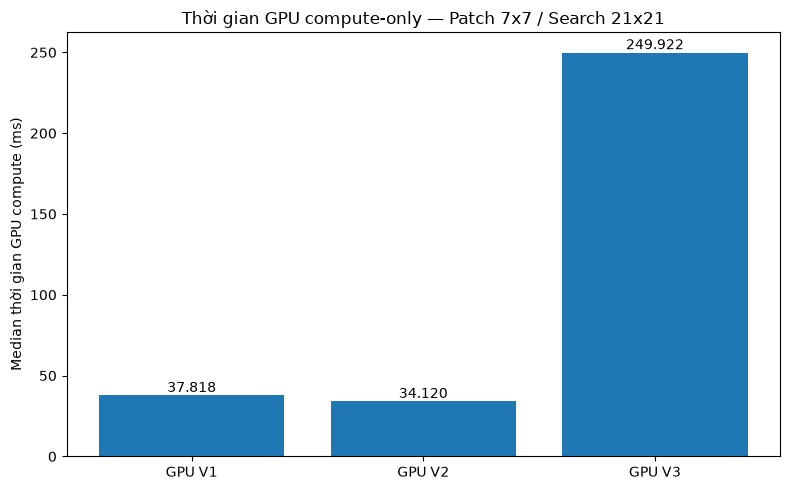

In [16]:

labels = ["GPU V1", "GPU V2", "GPU V3"]
values = [v1_compute_ms, v2_compute_ms, v3_compute_ms]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)
plt.ylabel("Median thời gian GPU compute (ms)")
plt.title("Thời gian GPU compute-only — Patch 7x7 / Search 21x21")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


## Benchmark steady-state end-to-end

In [18]:
v1_e2e = benchmark_gpu_end_to_end(
    function=run_v1_end_to_end,
    warmup_runs=5,
    measured_runs=20,
)

v2_e2e = benchmark_gpu_end_to_end(
    function=run_v2_end_to_end,
    warmup_runs=5,
    measured_runs=20,
)

v3_e2e = benchmark_gpu_end_to_end(
    function=run_v3_end_to_end,
    warmup_runs=5,
    measured_runs=20,
)

v1_e2e, v2_e2e, v3_e2e

({'times_seconds': array([0.0380843, 0.0380367, 0.0385153, 0.0383744, 0.0384219, 0.0383835,
         0.0383712, 0.0388351, 0.0382263, 0.0383135, 0.0382801, 0.038362 ,
         0.0384928, 0.0384909, 0.0386455, 0.0384184, 0.0379668, 0.0383009,
         0.039154 , 0.0415991]),
  'median_seconds': 0.03837895000469871,
  'mean_seconds': 0.03856363499944564,
  'std_seconds': 0.000742703345210575,
  'min_seconds': 0.03796679999504704,
  'max_seconds': 0.041599100004532374},
 {'times_seconds': array([0.0344263, 0.0350844, 0.0356566, 0.0344712, 0.0347539, 0.0349533,
         0.035054 , 0.0347596, 0.0349385, 0.0349336, 0.0345002, 0.0343883,
         0.0349839, 0.0348892, 0.0348085, 0.0345229, 0.0345745, 0.0350101,
         0.0353452, 0.035213 ]),
  'median_seconds': 0.034911400005512405,
  'mean_seconds': 0.03486335999987204,
  'std_seconds': 0.0003202918581270512,
  'min_seconds': 0.03438829998776782,
  'max_seconds': 0.03565659999730997},
 {'times_seconds': array([0.2493726, 0.2492132, 0.25373

In [19]:

v1_e2e_ms = v1_e2e["median_seconds"] * 1000.0
v2_e2e_ms = v2_e2e["median_seconds"] * 1000.0
v3_e2e_ms = v3_e2e["median_seconds"] * 1000.0

e2e_table = pd.DataFrame([
    {
        "Phiên bản": "GPU V1",
        "Median end-to-end (ms)": v1_e2e_ms,
        "Speedup so với V1": 1.0,
    },
    {
        "Phiên bản": "GPU V2",
        "Median end-to-end (ms)": v2_e2e_ms,
        "Speedup so với V1": v1_e2e_ms / v2_e2e_ms,
    },
    {
        "Phiên bản": "GPU V3",
        "Median end-to-end (ms)": v3_e2e_ms,
        "Speedup so với V1": v1_e2e_ms / v3_e2e_ms,
    },
])

e2e_table


,Phiên bản,Median end-to-end (ms),Speedup so với V1
0,GPU V1,38.37895,1.000000
1,GPU V2,34.91140,1.099324
2,GPU V3,251.43480,0.152640


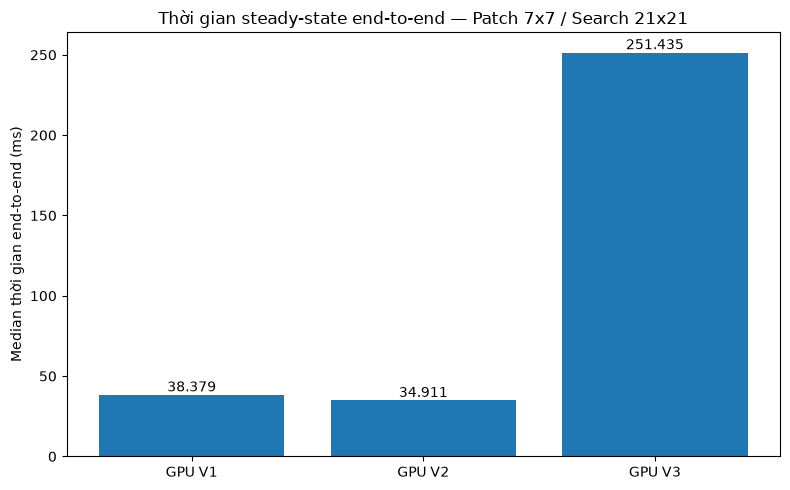

In [20]:

labels = ["GPU V1", "GPU V2", "GPU V3"]
values = [v1_e2e_ms, v2_e2e_ms, v3_e2e_ms]

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, values)
plt.ylabel("Median thời gian end-to-end (ms)")
plt.title("Thời gian steady-state end-to-end — Patch 7x7 / Search 21x21")

for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.3f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()


## Bảng tổng hợp kết quả

In [21]:

summary_table = pd.DataFrame([
    {
        "Phiên bản": "GPU V1",
        "Tối ưu chính": "Song song hóa theo output pixel",
        "GPU compute (ms)": v1_compute_ms,
        "End-to-end (ms)": v1_e2e_ms,
    },
    {
        "Phiên bản": "GPU V2",
        "Tối ưu chính": "Tái sử dụng dữ liệu bằng Shared Memory",
        "GPU compute (ms)": v2_compute_ms,
        "End-to-end (ms)": v2_e2e_ms,
    },
    {
        "Phiên bản": "GPU V3",
        "Tối ưu chính": "Tái sử dụng phép tính bằng running sum",
        "GPU compute (ms)": v3_compute_ms,
        "End-to-end (ms)": v3_e2e_ms,
    },
])

summary_table


,Phiên bản,Tối ưu chính,GPU compute (ms),End-to-end (ms)
0,GPU V1,Song song hóa theo output pixel,37.818367,38.37895
1,GPU V2,Tái sử dụng dữ liệu bằng Shared Memory,34.120192,34.91140
2,GPU V3,Tái sử dụng phép tính bằng running sum,249.922050,251.43480


## Hướng diễn giải kết quả

Dựa trên số liệu thực tế, chọn kết luận phù hợp.

### Trường hợp A — GPU V3 compute-only nhanh hơn V2

Kết quả này ủng hộ giả thuyết rằng running-sum giúp giảm phép tính patch-distance lặp lại ở cấu hình lớn `7×7 / 21×21`.

### Trường hợp B — GPU V3 compute-only chậm hơn V2

Đây vẫn là một kết quả hợp lệ. Một số nguyên nhân có thể là:

- phải launch nhiều CUDA kernel cho mỗi displacement;
- phát sinh thêm truy cập Global Memory cho buffer trung gian;
- overhead của running sum;
- workload chưa đủ lớn để bù chi phí preprocessing.

### Trường hợp C — GPU V3 compute-only nhanh hơn nhưng end-to-end không nhanh hơn

Điều này cho thấy phần tính toán CUDA đã được cải thiện, nhưng chi phí chuẩn bị dữ liệu, cấp phát bộ nhớ, truyền dữ liệu hoặc overhead của pipeline vẫn chiếm ưu thế.

Vì vậy notebook phải báo cáo đồng thời compute-only và end-to-end, không nên kết luận speedup chỉ dựa trên một phạm vi đo.

## Khung kết luận cuối cùng

Sau khi chạy notebook, cần kết luận:

1. GPU V3 có còn tương đương về mặt số học với GPU V1/V2 hay không.
2. Running-sum có giúp giảm thời gian GPU compute hay không.
3. Lợi ích đó có còn tồn tại ở mức end-to-end hay không.
4. Cấu hình patch/search nào làm tối ưu này bắt đầu có lợi.
5. Trade-off giữa việc giảm phép tính patch và chi phí preprocessing / multi-kernel pipeline.